In [102]:
columns = [
    "A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8", "A9",
    "A10", "A11", "A12", "A13", "A14", "A15", "Class"
]

In [103]:
import pandas as pd

# Cargar el archivo principal
df = pd.read_csv("./dataset/crx.data", header=None, names=columns, sep=",", skipinitialspace=True)

print(df.head())

  A1     A2     A3 A4 A5 A6 A7    A8 A9 A10  A11 A12 A13    A14  A15 Class
0  b  30.83  0.000  u  g  w  v  1.25  t   t    1   f   g  00202    0     +
1  a  58.67  4.460  u  g  q  h  3.04  t   t    6   f   g  00043  560     +
2  a  24.50  0.500  u  g  q  h  1.50  t   f    0   f   g  00280  824     +
3  b  27.83  1.540  u  g  w  v  3.75  t   t    5   t   g  00100    3     +
4  b  20.17  5.625  u  g  w  v  1.71  t   f    0   f   s  00120    0     +


In [104]:
df = df.replace("?", pd.NA)


In [105]:
df["Class"] = df["Class"].map({"+":1, "-":0})


In [106]:
numeric_cols = ["A2","A3","A8","A11","A14","A15"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")


In [107]:
print(df.info())
print(df.describe(include="all"))


<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    str    
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    str    
 4   A5      684 non-null    str    
 5   A6      681 non-null    str    
 6   A7      681 non-null    str    
 7   A8      690 non-null    float64
 8   A9      690 non-null    str    
 9   A10     690 non-null    str    
 10  A11     690 non-null    int64  
 11  A12     690 non-null    str    
 12  A13     690 non-null    str    
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  Class   690 non-null    int64  
dtypes: float64(4), int64(3), str(9)
memory usage: 86.4 KB
None
         A1          A2          A3   A4   A5   A6   A7          A8   A9  A10  \
count   678  678.000000  690.000000  684  684  681  681  690.000000  690  690   
unique    2   

In [108]:
print(df.isnull().sum())

A1       12
A2       12
A3        0
A4        6
A5        6
A6        9
A7        9
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14      13
A15       0
Class     0
dtype: int64


In [109]:
df.isnull().sum()
df = df.dropna()
print(df.info())

<class 'pandas.DataFrame'>
Index: 653 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      653 non-null    str    
 1   A2      653 non-null    float64
 2   A3      653 non-null    float64
 3   A4      653 non-null    str    
 4   A5      653 non-null    str    
 5   A6      653 non-null    str    
 6   A7      653 non-null    str    
 7   A8      653 non-null    float64
 8   A9      653 non-null    str    
 9   A10     653 non-null    str    
 10  A11     653 non-null    int64  
 11  A12     653 non-null    str    
 12  A13     653 non-null    str    
 13  A14     653 non-null    float64
 14  A15     653 non-null    int64  
 15  Class   653 non-null    int64  
dtypes: float64(4), int64(3), str(9)
memory usage: 86.7 KB
None


In [110]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

print("Categóricas:", len(categorical_cols))
print("Numéricas:", len(numeric_cols))

Categóricas: 9
Numéricas: 7


C:\Users\aaran\AppData\Local\Temp\ipykernel_16232\775572787.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [111]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [112]:
from sklearn.preprocessing import OneHotEncoder

# En scikit-learn >= 1.2
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded = encoder.fit_transform(df[categorical_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df.index
)

dataset_final = pd.concat([df[numeric_cols], encoded_df, df["Class"]], axis=1)

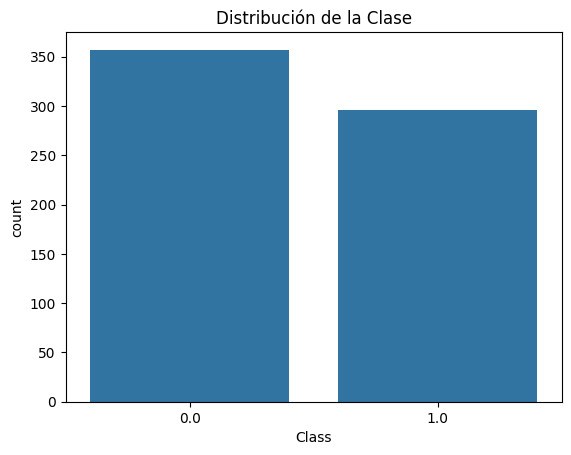

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x="Class", data=df)
plt.title("Distribución de la Clase")
plt.show()

In [114]:
df.Class

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
685    0.0
686    0.0
687    0.0
688    0.0
689    0.0
Name: Class, Length: 653, dtype: float64

## DESDE AQUI EMPEZAMOS CON EL ENTRENAMIENTO ##

Segun las caracteristicas del dataset, este es ideal para realizar una clasificacion logistica binaria ya que se cuenta con dos clases.

In [132]:
import numpy as np
import matplotlib as plt
from matplotlib import pyplot

In [130]:
x = df
y = df['Class']
x = x.drop('Class', axis=1)
x = x.drop(categorical_cols, axis=1)


x2 = np.array(x)
y2 = np.array(y)
print(x2, y2)

x.count()

[[3.083e+01 0.000e+00 1.250e+00 1.000e+00 2.020e+02 0.000e+00]
 [5.867e+01 4.460e+00 3.040e+00 6.000e+00 4.300e+01 5.600e+02]
 [2.450e+01 5.000e-01 1.500e+00 0.000e+00 2.800e+02 8.240e+02]
 ...
 [2.525e+01 1.350e+01 2.000e+00 1.000e+00 2.000e+02 1.000e+00]
 [1.792e+01 2.050e-01 4.000e-02 0.000e+00 2.800e+02 7.500e+02]
 [3.500e+01 3.375e+00 8.290e+00 0.000e+00 0.000e+00 0.000e+00]] [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1

A2     653
A3     653
A8     653
A11    653
A14    653
A15    653
dtype: int64

## Funcion Sigmoide ##

In [122]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

In [123]:
# Prueba la implementacion de la funcion sigmoid
z = [-100, 0.5, 1000000]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


In [124]:
## Funcion calcular costo
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [125]:
# Descenso por el gradiente 
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

theta calculado por el descenso por el gradiente: [-0.03102291  0.0088013   0.03763968  0.03566842 -0.04514675  0.45925465]
Un estudiante con nota del examen 1: 80 y nota del examen 2: 46 (usando el descenso por el gradiente):1


C:\Users\aaran\AppData\Local\Temp\ipykernel_16232\2641740994.py:8: RuntimeWarning: divide by zero encountered in log
  J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
C:\Users\aaran\AppData\Local\Temp\ipykernel_16232\2641740994.py:8: RuntimeWarning: invalid value encountered in dot
  J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
C:\Users\aaran\AppData\Local\Temp\ipykernel_16232\714609262.py:8: RuntimeWarning: overflow encountered in exp
  g = 1 / (1 + np.exp(-z))


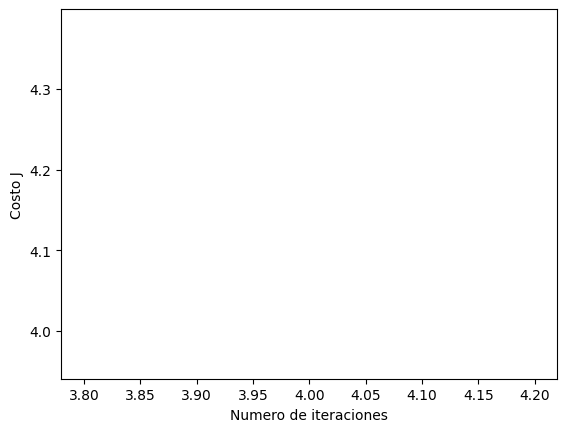

In [135]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 100

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(6)
theta, J_history = descensoGradiente(theta, x2, y2, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))


X_array = [2.525e+01, 2.525e+01, 2.525e+01, 2.525e+01, 2.525e+01, 2.525e+01]
aprueba = sigmoid(np.dot(X_array, theta)) 

print('Un estudiante con nota del examen 1: 80 y nota del examen 2: 46 (usando el descenso por el gradiente):{:.0f}'.format(aprueba))